# AI Marketing Decision System  
## Final Exam Project
- Course: AI for Marketing Decisions
- Group: AIB-2401
- Students: Nazerke Zhumadilova, Inzhu Nurlan
- Professor: Mohamed Ali Ibrahim

### Project Introduction

This project focuses on building an AI-driven marketing decision system using two real-world datasets. The main dataset, **Customer Personality Analysis**, is used to understand customer behavior, purchasing patterns, campaign responses, and customer segments. The second dataset, **171k Product Review with Sentiment**, is used to analyze customer opinions through review text and sentiment labels.

The goal of this project is to show how marketing teams can use data analytics, machine learning, recommendation logic, and natural language processing to make better business decisions. Instead of relying only on general assumptions, the system uses customer data to identify valuable segments, predict customer behavior, personalize offers, and understand how customers feel about products.

The project is divided into several analytical tasks. First, the data is cleaned and prepared for analysis. Then, exploratory data analysis is used to find important patterns in customer behavior. After that, machine learning methods are applied for customer segmentation and predictive modeling. A recommendation system is also developed to support personalization. Finally, sentiment analysis is used to understand customer feedback from product reviews.

The results of this notebook will later be used to support the Power BI dashboard, where the main insights, model outputs, customer segments, and marketing recommendations will be visualized for business decision-making.

### Project Objective

The main objective of this project is to develop an AI-based marketing decision system that helps a company better understand its customers, improve campaign targeting, personalize product recommendations, and analyze customer feedback.

The project combines customer analytics, machine learning, recommendation logic, and sentiment analysis. By using these methods, the company can move from general marketing decisions to more data-driven and customer-focused strategies.

### Project Goals

The goals of this project are:

1. To clean and prepare customer and review datasets for further analysis.
2. To explore customer behavior, spending patterns, and campaign responses.
3. To segment customers into meaningful groups using K-Means clustering.
4. To build a predictive model for customer behavior or campaign response.
5. To create a simple recommendation system for personalized marketing.
6. To analyze customer sentiment from product reviews using NLP methods.
7. To transform the results into clear business insights for Power BI dashboard and final presentation.

### Business Problem

Many companies collect customer data, but they often do not use it effectively for marketing decisions. Without proper analysis, it is difficult to understand which customers are the most valuable, which campaigns work better, which customers may stop buying, and what people really think about products.

This project addresses this problem by creating a data-driven marketing intelligence system. The system helps marketers identify customer segments, predict behavior, recommend relevant products, and understand customer opinions through sentiment analysis.

In [19]:
# Import main libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Task 1 — Data Cleaning and Customer Data Preparation

The first task focuses on preparing both datasets for further analysis. Real marketing datasets often contain missing values, duplicate records, inconsistent data types, and columns that need to be transformed before analysis.

In this section, we clean the customer dataset and the sentiment dataset. For the customer dataset, we check missing values, remove unnecessary technical columns, convert date columns, and create new marketing features such as Age, Total Spending, Total Purchases, Average Order Value, Family Size, Campaign Acceptance, and Customer Tenure. These features will later be used for exploratory analysis, customer segmentation, predictive modeling, and Power BI visualization.

For the sentiment dataset, we remove missing values, duplicate reviews, and convert product price and rating into numeric format. This prepares the review data for sentiment analysis and customer feedback insights.

In [20]:
# Load datasets

customer_df = pd.read_csv("marketing_campaign.csv", sep="\t")
sentiment_df = pd.read_csv("sentiment.csv", encoding="latin1")

print("Customer dataset shape:", customer_df.shape)
print("Sentiment dataset shape:", sentiment_df.shape)

display(customer_df.head())
display(sentiment_df.head())

Customer dataset shape: (2240, 29)
Sentiment dataset shape: (171380, 6)


/tmp/ipykernel_5660/3493569182.py:4: DtypeWarning: Columns (1,2) have mixed types. Specify dtype option on import or set low_memory=False.
  sentiment_df = pd.read_csv("sentiment.csv", encoding="latin1")


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


,ProductName,ProductPrice,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,Super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,Awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,Fair,the quality is good but the power of air is de...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,Useless product,very bad product its a only a fan,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,Fair,ok ok product,neutral


In [3]:
# Check basic information about customer dataset

print("Customer dataset info:")
customer_df.info()

print("\nMissing values in customer dataset:")
print(customer_df.isnull().sum())

print("\nDuplicate rows in customer dataset:")
print(customer_df.duplicated().sum())

Customer dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchas

In [4]:
# Check basic information about sentiment dataset

print("Sentiment dataset info:")
sentiment_df.info()

print("\nMissing values in sentiment dataset:")
print(sentiment_df.isnull().sum())

print("\nDuplicate rows in sentiment dataset:")
print(sentiment_df.duplicated().sum())

Sentiment dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72513 entries, 0 to 72512
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ProductName   72513 non-null  object
 1   ProductPrice  72513 non-null  object
 2   Rate          72513 non-null  object
 3   Review        72513 non-null  object
 4   Summary       72513 non-null  object
 5   Sentiment     72512 non-null  object
dtypes: object(6)
memory usage: 3.3+ MB

Missing values in sentiment dataset:
ProductName     0
ProductPrice    0
Rate            0
Review          0
Summary         0
Sentiment       1
dtype: int64

Duplicate rows in sentiment dataset:
12570


In [5]:
# Clean customer dataset

customer_clean = customer_df.copy()

# Fill missing Income with median value
customer_clean["Income"] = customer_clean["Income"].fillna(customer_clean["Income"].median())

# Convert customer registration date to datetime format
customer_clean["Dt_Customer"] = pd.to_datetime(customer_clean["Dt_Customer"], format="%d-%m-%Y")

# Remove technical columns that do not help the analysis
customer_clean = customer_clean.drop(columns=["Z_CostContact", "Z_Revenue"])

# Check result
print("Missing values after cleaning:")
print(customer_clean.isnull().sum().sum())

print("Customer dataset shape after cleaning:", customer_clean.shape)
display(customer_clean.head())

Missing values after cleaning:
0
Customer dataset shape after cleaning: (2240, 27)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,0,0,0,0,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,0,0,0,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,0,0,0,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,0,0,0,0,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,0,0,0,0,0


In [6]:
# Clean sentiment dataset

sentiment_clean = sentiment_df.copy()

# Remove rows with missing sentiment
sentiment_clean = sentiment_clean.dropna(subset=["Sentiment"])

# Remove duplicate rows
sentiment_clean = sentiment_clean.drop_duplicates()

# Convert price and rating to numeric format
sentiment_clean["ProductPrice"] = pd.to_numeric(sentiment_clean["ProductPrice"], errors="coerce")
sentiment_clean["Rate"] = pd.to_numeric(sentiment_clean["Rate"], errors="coerce")

# Remove rows where price or rating could not be converted
sentiment_clean = sentiment_clean.dropna(subset=["ProductPrice", "Rate"])

# Check result
print("Missing values after cleaning:")
print(sentiment_clean.isnull().sum().sum())

print("Sentiment dataset shape after cleaning:", sentiment_clean.shape)
display(sentiment_clean.head())

Missing values after cleaning:
0
Sentiment dataset shape after cleaning: (59941, 6)


,ProductName,ProductPrice,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999.0,5.0,Super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999.0,5.0,Awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999.0,3.0,Fair,the quality is good but the power of air is de...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999.0,1.0,Useless product,very bad product its a only a fan,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999.0,3.0,Fair,ok ok product,neutral


In [7]:
# Feature engineering for customer dataset

# Create customer age
customer_clean["Age"] = 2026 - customer_clean["Year_Birth"]

# Create total spending across all product categories
customer_clean["Total_Spending"] = (
    customer_clean["MntWines"] +
    customer_clean["MntFruits"] +
    customer_clean["MntMeatProducts"] +
    customer_clean["MntFishProducts"] +
    customer_clean["MntSweetProducts"] +
    customer_clean["MntGoldProds"]
)

# Create total number of purchases across all channels
customer_clean["Total_Purchases"] = (
    customer_clean["NumWebPurchases"] +
    customer_clean["NumCatalogPurchases"] +
    customer_clean["NumStorePurchases"]
)

# Create average order value
customer_clean["Average_Order_Value"] = customer_clean["Total_Spending"] / customer_clean["Total_Purchases"]

# Replace infinite values with 0 if customer has no purchases
customer_clean["Average_Order_Value"] = customer_clean["Average_Order_Value"].replace([np.inf, -np.inf], 0)

# Create family size
customer_clean["Family_Size"] = (
    customer_clean["Kidhome"] +
    customer_clean["Teenhome"] +
    customer_clean["Marital_Status"].replace({
        "Single": 1,
        "Alone": 1,
        "Divorced": 1,
        "Widow": 1,
        "YOLO": 1,
        "Absurd": 1,
        "Married": 2,
        "Together": 2
    })
)

# Create parent status
customer_clean["Is_Parent"] = np.where(
    (customer_clean["Kidhome"] + customer_clean["Teenhome"]) > 0, 1, 0
)

# Create total campaign acceptance
customer_clean["Campaign_Acceptance"] = (
    customer_clean["AcceptedCmp1"] +
    customer_clean["AcceptedCmp2"] +
    customer_clean["AcceptedCmp3"] +
    customer_clean["AcceptedCmp4"] +
    customer_clean["AcceptedCmp5"] +
    customer_clean["Response"]
)

# Create customer tenure in days
latest_date = customer_clean["Dt_Customer"].max()
customer_clean["Customer_Tenure_Days"] = (latest_date - customer_clean["Dt_Customer"]).dt.days

# Check new columns
new_columns = [
    "Age",
    "Total_Spending",
    "Total_Purchases",
    "Average_Order_Value",
    "Family_Size",
    "Is_Parent",
    "Campaign_Acceptance",
    "Customer_Tenure_Days"
]

display(customer_clean[new_columns].head())

/tmp/ipykernel_5660/1813855466.py:33: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  customer_clean["Marital_Status"].replace({


,Age,Total_Spending,Total_Purchases,Average_Order_Value,Family_Size,Is_Parent,Campaign_Acceptance,Customer_Tenure_Days
0,69,1617,22,73.500000,1,0,1,663
1,72,27,4,6.750000,3,1,0,113
2,61,776,20,38.800000,2,0,0,312
3,42,53,6,8.833333,3,1,0,139
4,45,422,14,30.142857,3,1,0,161


In [8]:
# Summary statistics for new features

customer_clean[
    [
        "Age",
        "Income",
        "Total_Spending",
        "Total_Purchases",
        "Average_Order_Value",
        "Family_Size",
        "Campaign_Acceptance",
        "Customer_Tenure_Days"
    ]
].describe()

,Age,Income,Total_Spending,Total_Purchases,Average_Order_Value,Family_Size,Campaign_Acceptance,Customer_Tenure_Days
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,57.194196,52237.975446,605.798214,12.537054,38.103486,2.595089,0.446875,353.582143
std,11.984069,25037.955891,602.249288,7.205741,45.910552,0.906959,0.890543,202.122512
min,30.000000,1730.000000,5.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,49.000000,35538.750000,68.750000,6.000000,13.000000,2.000000,0.000000,180.750000
50%,56.000000,51381.500000,396.000000,12.000000,29.642857,3.000000,0.000000,355.500000
75%,67.000000,68289.750000,1045.500000,18.000000,49.135417,3.000000,1.000000,529.000000
max,133.000000,666666.000000,2525.000000,32.000000,1679.000000,5.000000,5.000000,699.000000


In [9]:
# Remove unrealistic outliers

# Keep customers with realistic age
customer_clean = customer_clean[customer_clean["Age"] <= 100]

# Keep customers with realistic income
customer_clean = customer_clean[customer_clean["Income"] <= 200000]

print("Customer dataset shape after removing outliers:", customer_clean.shape)

customer_clean[
    [
        "Age",
        "Income",
        "Total_Spending",
        "Total_Purchases",
        "Average_Order_Value",
        "Family_Size",
        "Campaign_Acceptance",
        "Customer_Tenure_Days"
    ]
].describe()

Customer dataset shape after removing outliers: (2236, 35)


,Age,Income,Total_Spending,Total_Purchases,Average_Order_Value,Family_Size,Campaign_Acceptance,Customer_Tenure_Days
count,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000
mean,57.101968,51952.614043,605.986583,12.546512,38.099401,2.595707,0.447227,353.773256
std,11.703281,21411.466851,601.865156,7.206577,45.896492,0.907468,0.891113,202.181561
min,30.000000,1730.000000,5.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,49.000000,35502.500000,69.000000,6.000000,13.000000,2.000000,0.000000,180.750000
50%,56.000000,51381.500000,396.500000,12.000000,29.688095,3.000000,0.000000,356.000000
75%,67.000000,68275.750000,1045.500000,18.000000,49.135417,3.000000,1.000000,529.000000
max,86.000000,162397.000000,2525.000000,32.000000,1679.000000,5.000000,5.000000,699.000000


In [10]:
# Additional required marketing features

# Customer Lifetime Value can be represented by total historical spending in this dataset
customer_clean["Customer_Lifetime_Value"] = customer_clean["Total_Spending"]

# Days since last purchase is already represented by Recency in the original dataset
customer_clean["Days_Since_Last_Purchase"] = customer_clean["Recency"]

# Purchase frequency: number of purchases per customer tenure period
customer_clean["Purchase_Frequency"] = customer_clean["Total_Purchases"] / (customer_clean["Customer_Tenure_Days"] + 1)

# Check final required features
required_features = [
    "Customer_Lifetime_Value",
    "Average_Order_Value",
    "Purchase_Frequency",
    "Days_Since_Last_Purchase"
]

display(customer_clean[required_features].head())

print("Final customer dataset shape:", customer_clean.shape)

,Customer_Lifetime_Value,Average_Order_Value,Purchase_Frequency,Days_Since_Last_Purchase
0,1617,73.500000,0.033133,58
1,27,6.750000,0.035088,38
2,776,38.800000,0.063898,26
3,53,8.833333,0.042857,26
4,422,30.142857,0.086420,94


Final customer dataset shape: (2236, 38)


### Task 1 Interpretation

After checking the customer dataset, only the Income column had missing values. These missing values were replaced with the median income because the median is more stable when the dataset contains high-income outliers. The customer registration date was also converted into datetime format so that customer tenure could be calculated correctly.

Several new features were created to support marketing analysis. Age helps describe customer demographics. Total Spending shows how much each customer spent across all product categories. Total Purchases combines web, catalog, and store purchases. Average Order Value shows the average amount spent per purchase. Family Size and Is Parent help understand household structure, while Campaign Acceptance shows how many campaigns each customer responded to.

The sentiment dataset was cleaned by removing missing sentiment labels, duplicate reviews, and invalid numeric values in product price and rating. After cleaning, the customer dataset had 2236 rows, and the sentiment dataset had 59941 rows. The data is now ready for exploratory data analysis, segmentation, predictive modeling, recommendation logic, and sentiment analysis.To fully match the project requirements, additional calculated marketing features were created. Customer_Lifetime_Value was represented by total historical spending, Days_Since_Last_Purchase was based on the Recency column, and Purchase_Frequency was calculated as total purchases divided by customer tenure. These variables make the dataset more suitable for segmentation, prediction, and marketing decision-making.

## Task 2 — Exploratory Data Analysis and Customer Insights

The second task focuses on understanding customer behavior through exploratory data analysis. In this section, we analyze spending patterns, customer demographics, campaign responses, time-based trends, and unusual customer behavior.

The goal of this stage is not only to create charts, but also to explain what these charts show about customers. This helps marketing teams understand which customer groups are more valuable, which campaigns perform better, and whether there are VIP customers or possible outliers in the dataset.

In [11]:
# Import visualization libraries

import seaborn as sns
import matplotlib.pyplot as plt

# Create age groups for demographic analysis
customer_clean["Age_Group"] = pd.cut(
    customer_clean["Age"],
    bins=[29, 40, 50, 60, 70, 90],
    labels=["30-40", "41-50", "51-60", "61-70", "70+"]
)

# Create month and year columns from customer registration date
customer_clean["Customer_Year"] = customer_clean["Dt_Customer"].dt.year
customer_clean["Customer_Month"] = customer_clean["Dt_Customer"].dt.month
customer_clean["Customer_YearMonth"] = customer_clean["Dt_Customer"].dt.to_period("M").astype(str)

display(customer_clean[["Age", "Age_Group", "Dt_Customer", "Customer_YearMonth"]].head())

,Age,Age_Group,Dt_Customer,Customer_YearMonth
0,69,61-70,2012-09-04,2012-09
1,72,70+,2014-03-08,2014-03
2,61,61-70,2013-08-21,2013-08
3,42,41-50,2014-02-10,2014-02
4,45,41-50,2014-01-19,2014-01


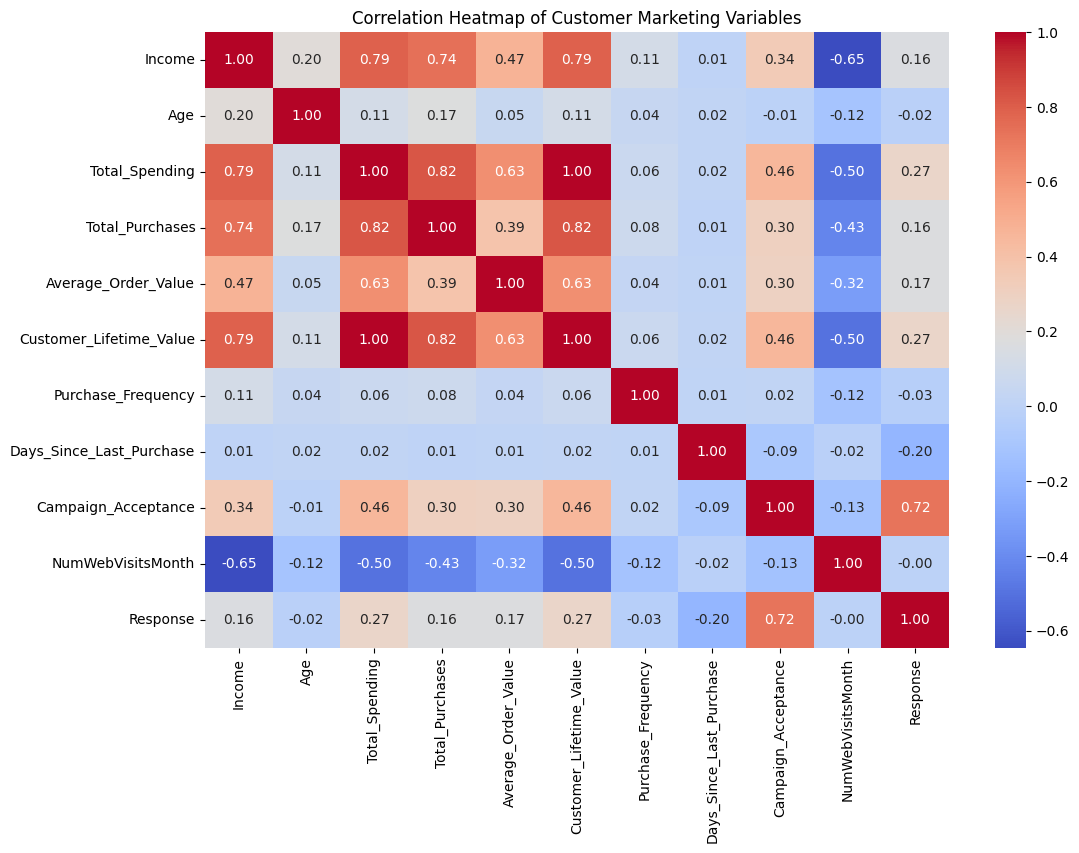

In [12]:
# Correlation heatmap for main numerical marketing variables

corr_columns = [
    "Income",
    "Age",
    "Total_Spending",
    "Total_Purchases",
    "Average_Order_Value",
    "Customer_Lifetime_Value",
    "Purchase_Frequency",
    "Days_Since_Last_Purchase",
    "Campaign_Acceptance",
    "NumWebVisitsMonth",
    "Response"
]

plt.figure(figsize=(12, 8))
sns.heatmap(customer_clean[corr_columns].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Customer Marketing Variables")
plt.show()

### Correlation Heatmap Interpretation

The correlation heatmap shows that Income has a strong positive relationship with Total Spending (0.79) and Total Purchases (0.74). This means that higher-income customers usually spend more and buy more often. Total Spending and Total Purchases are also strongly connected (0.82), which confirms that frequent buyers are the main revenue drivers.

Another important finding is the negative relationship between NumWebVisitsMonth and Income (-0.65), Total Spending (-0.50), and Total Purchases (-0.43). This means that customers who visit the website more often are not always the highest spenders. They may compare products more, browse without buying, or need stronger conversion-focused marketing.

Campaign Acceptance has a strong relationship with Response (0.72). This shows that customers who accepted previous campaigns are more likely to respond again. Therefore, previous campaign behavior is an important signal for future targeting.

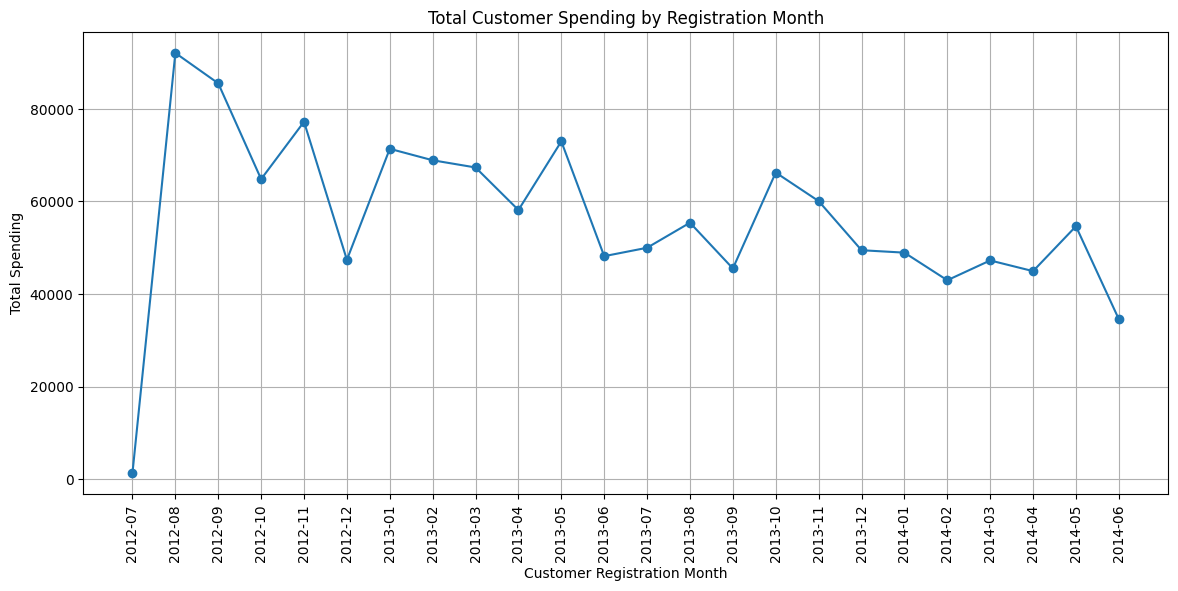

In [13]:
# Time-series trend of total spending by customer registration month

monthly_spending = customer_clean.groupby("Customer_YearMonth")["Total_Spending"].sum().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(monthly_spending["Customer_YearMonth"], monthly_spending["Total_Spending"], marker="o")
plt.title("Total Customer Spending by Registration Month")
plt.xlabel("Customer Registration Month")
plt.ylabel("Total Spending")
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

### Time-Series Trend Interpretation

The time-series chart shows total customer spending by customer registration month. The highest spending appears around August and September 2012, where registered customers generated the largest total value. After that, total spending becomes more stable but generally lower, with several smaller peaks in 2013 and 2014.

This means that some registration periods brought more valuable customers than others. For the marketing team, this can indicate that certain campaign periods, seasonal factors, or customer acquisition channels were more effective in attracting high-value customers.

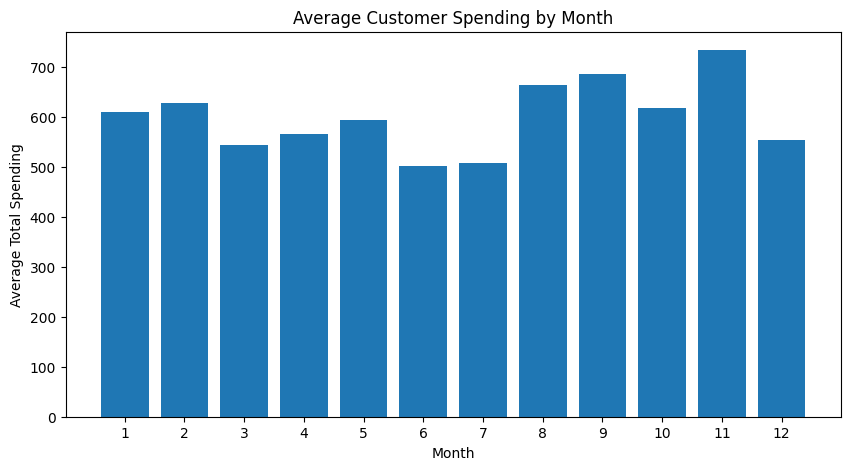

In [14]:
# Seasonal pattern by registration month

monthly_pattern = customer_clean.groupby("Customer_Month")["Total_Spending"].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.bar(monthly_pattern["Customer_Month"], monthly_pattern["Total_Spending"])
plt.title("Average Customer Spending by Month")
plt.xlabel("Month")
plt.ylabel("Average Total Spending")
plt.xticks(range(1, 13))
plt.show()

### Seasonal Spending Interpretation

The monthly spending chart shows that average customer spending is highest in November, followed by September and August. This suggests a possible seasonal increase in customer value in late summer and autumn. June and July show the lowest average spending, which may indicate weaker customer activity during these months.

For marketing decisions, this means the company can increase promotional campaigns before high-spending months and use lower-spending months for retention campaigns, discounts, or reactivation offers.

/tmp/ipykernel_5660/3661690620.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_spending = customer_clean.groupby("Age_Group")["Total_Spending"].mean().reset_index()


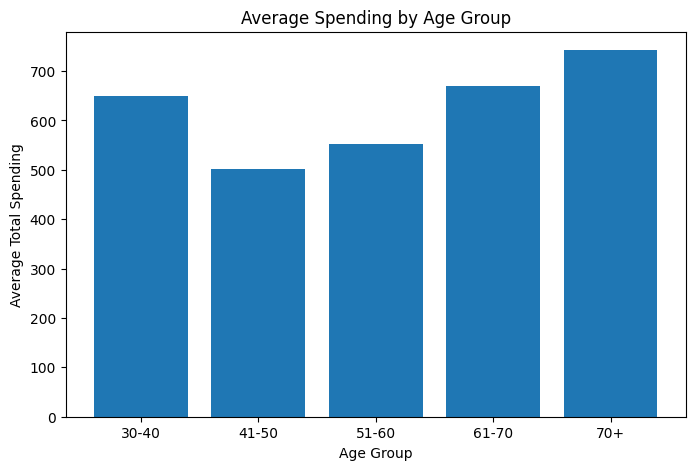

In [15]:
# Average spending by age group

age_spending = customer_clean.groupby("Age_Group")["Total_Spending"].mean().reset_index()

plt.figure(figsize=(8, 5))
plt.bar(age_spending["Age_Group"], age_spending["Total_Spending"])
plt.title("Average Spending by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Total Spending")
plt.show()

### Age Group Interpretation

The age group chart shows that customers aged 70+ have the highest average spending, followed by customers aged 61–70 and 30–40. The lowest average spending is seen among customers aged 41–50. This means that older customers are especially valuable for this company.

For marketing strategy, the company should not focus only on younger customers. Older customer groups may respond better to premium offers, loyalty programs, and personalized product recommendations.

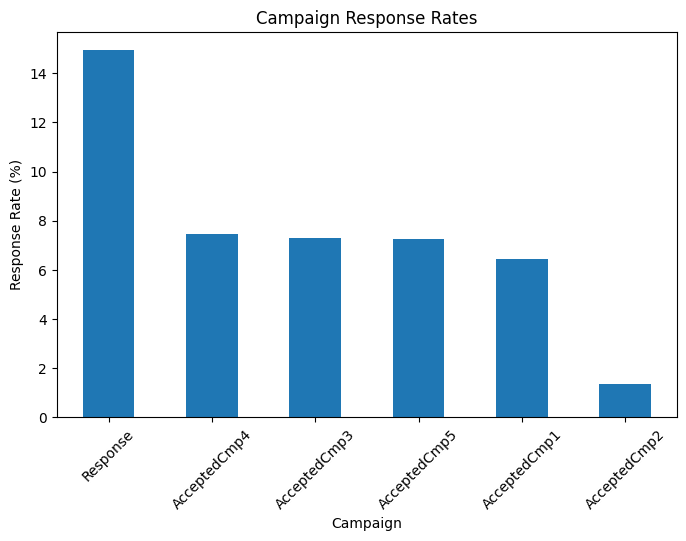

,0
Response,14.937388
AcceptedCmp4,7.468694
AcceptedCmp3,7.289803
AcceptedCmp5,7.245081
AcceptedCmp1,6.440072
AcceptedCmp2,1.341682


In [16]:
# Campaign response rates

campaign_columns = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

campaign_rates = customer_clean[campaign_columns].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(8, 5))
campaign_rates.plot(kind="bar")
plt.title("Campaign Response Rates")
plt.xlabel("Campaign")
plt.ylabel("Response Rate (%)")
plt.xticks(rotation=45)
plt.show()

display(campaign_rates)

### Campaign Response Interpretation

The campaign response chart shows that the latest campaign Response has the highest response rate at about 14.94%. Among previous campaigns, AcceptedCmp4 has the strongest result at about 7.47%, followed by AcceptedCmp3 at 7.29% and AcceptedCmp5 at 7.25%. AcceptedCmp2 has the weakest response rate, only about 1.34%.

This means that not all campaigns performed equally well. The company should study the structure of the latest campaign and Campaign 4 because they attracted more customer attention. Campaign 2 may need to be redesigned with better targeting, offer quality, or communication.

In [17]:
# Detect VIP customers using top 5% of total spending

vip_threshold = customer_clean["Total_Spending"].quantile(0.95)

vip_customers = customer_clean[customer_clean["Total_Spending"] >= vip_threshold]

print("VIP spending threshold:", vip_threshold)
print("Number of VIP customers:", vip_customers.shape[0])

display(
    vip_customers[
        ["ID", "Income", "Age", "Total_Spending", "Total_Purchases", "Average_Order_Value", "Campaign_Acceptance"]
    ].sort_values(by="Total_Spending", ascending=False).head(10)
)

VIP spending threshold: 1767.5
Number of VIP customers: 112


,ID,Income,Age,Total_Spending,Total_Purchases,Average_Order_Value,Campaign_Acceptance
1572,5350,90638.0,35,2525,17,148.529412,2
1179,5735,90638.0,35,2525,17,148.529412,1
1492,1763,87679.0,38,2524,28,90.142857,4
987,4580,75759.0,57,2486,25,99.440000,4
1052,4475,69098.0,77,2440,24,101.666667,0
1601,5453,90226.0,70,2352,23,102.260870,1
1458,10133,93790.0,56,2349,25,93.960000,4
1288,9010,83151.0,54,2346,22,106.636364,4
943,5386,94384.0,73,2302,18,127.888889,4
1301,6024,94384.0,73,2302,18,127.888889,4


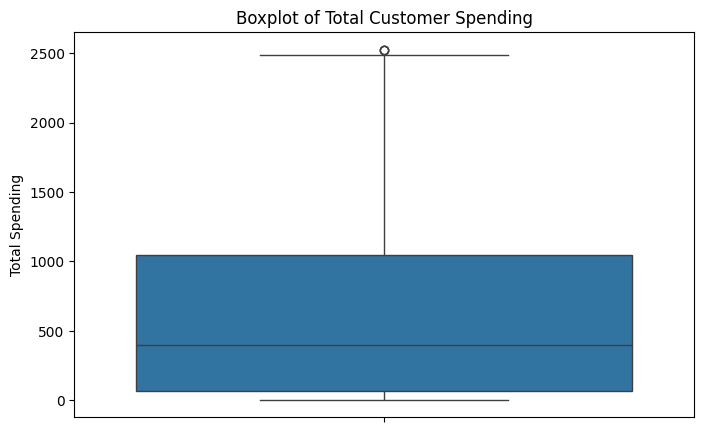

In [18]:
# Boxplot to visualize spending outliers

plt.figure(figsize=(8, 5))
sns.boxplot(y=customer_clean["Total_Spending"])
plt.title("Boxplot of Total Customer Spending")
plt.ylabel("Total Spending")
plt.show()

### Outlier and VIP Customer Interpretation

The VIP analysis identifies customers in the top 5% of Total Spending. The VIP threshold is 1767.5, and 112 customers belong to this high-value group. These customers spend much more than the average customer and should be treated as a priority segment.

The top VIP customers spent around 2524–2525 in total and many of them also accepted several campaigns. This means that VIP customers are not only high spenders, but some of them are also responsive to marketing communication. The company can use personalized offers, loyalty rewards, and exclusive campaigns to retain this group.

The boxplot confirms that most customers spend below the VIP level, while a small number of customers spend much more. These high-spending customers are not necessarily errors; they are valuable customers who can strongly influence total revenue.

### Task 2 Summary

The exploratory data analysis shows that customer value is strongly connected with income, purchase activity, and campaign responsiveness. Higher-income customers usually spend more, while customers who accepted past campaigns are more likely to respond again. The analysis also shows that website visits alone do not guarantee higher spending, so the company should focus not only on traffic but also on conversion quality.

The seasonal analysis shows stronger average spending in late summer and autumn, especially in November. Demographic analysis shows that older customers, especially the 70+ and 61–70 groups, generate higher average spending. Campaign analysis shows that the latest campaign and Campaign 4 performed better than the others, while Campaign 2 performed weakest.

The VIP analysis found 112 high-value customers with spending above 1767.5. This group should receive special attention through loyalty programs, personalized recommendations, and retention campaigns. Overall, Task 2 gives a clear business understanding of who the valuable customers are, when spending is higher, and which campaign signals matter most.

## Task 3 — Customer Segmentation and Targeting Model

In this task, K-Means clustering is used to divide customers into meaningful marketing segments. The goal is to group customers based on demographic and behavioral features such as income, age, spending, purchase activity, campaign acceptance, and recency.

Before applying K-Means, the selected variables are standardized because clustering is distance-based. If the variables are not scaled, columns with larger values, such as Income or Total Spending, can dominate the clustering result. The Elbow Method is used to choose the optimal number of clusters. After that, each cluster is profiled and given a clear business label with a suitable marketing strategy.

In [21]:
# Select features for customer segmentation

segmentation_features = [
    "Income",
    "Age",
    "Total_Spending",
    "Total_Purchases",
    "Average_Order_Value",
    "Days_Since_Last_Purchase",
    "Campaign_Acceptance",
    "NumWebVisitsMonth",
    "Is_Parent"
]

X_segmentation = customer_clean[segmentation_features]

# Standardize features for K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_segmentation)

print("Segmentation data shape:", X_scaled.shape)

Segmentation data shape: (2236, 9)


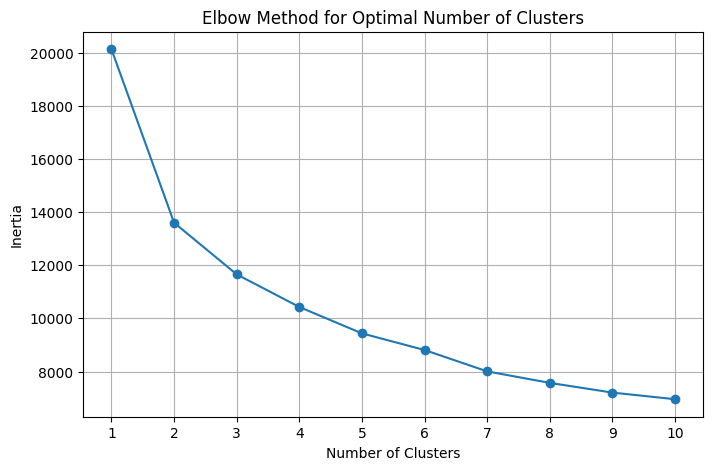

In [22]:
# Elbow Method to find the optimal number of clusters

inertia_values = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia_values, marker="o")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [29]:
# Apply K-Means clustering with 3 clusters

kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)

customer_clean["Cluster"] = kmeans_final.fit_predict(X_scaled)

print("Number of customers in each cluster:")
print(customer_clean["Cluster"].value_counts().sort_index())

Number of customers in each cluster:
Cluster
0    1087
1     499
2     650
Name: count, dtype: int64


### Elbow Method Interpretation

The Elbow Method was used to determine the optimal number of customer clusters. The curve shows a strong decrease in inertia from 1 to 3 clusters, after which the improvement becomes smaller. Although 4 clusters could also be considered, the 4-cluster solution created one very small segment with only one customer. This is not useful for business targeting because a segment should represent a meaningful customer group.

Therefore, the final model uses 3 clusters. This gives a more stable and interpretable customer segmentation for marketing decisions.

In [30]:
# Profile each customer segment

cluster_profile = customer_clean.groupby("Cluster")[
    [
        "Income",
        "Age",
        "Total_Spending",
        "Total_Purchases",
        "Average_Order_Value",
        "Days_Since_Last_Purchase",
        "Campaign_Acceptance",
        "NumWebVisitsMonth",
        "Is_Parent"
    ]
].mean().round(2)

display(cluster_profile)

,Income,Age,Total_Spending,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Campaign_Acceptance,NumWebVisitsMonth,Is_Parent
Cluster,,,,,,,,,
0,34647.99,54.31,114.28,6.26,15.40,48.76,0.18,6.59,0.88
1,77408.54,57.44,1407.70,19.03,79.61,49.92,1.18,2.62,0.05
2,61348.96,61.52,812.81,18.08,44.19,49.10,0.32,5.27,0.96


In [31]:
# Segment size and percentage

segment_size = customer_clean["Cluster"].value_counts().sort_index().reset_index()
segment_size.columns = ["Cluster", "Customer_Count"]

segment_size["Percentage"] = (
    segment_size["Customer_Count"] / segment_size["Customer_Count"].sum() * 100
).round(2)

display(segment_size)

,Cluster,Customer_Count,Percentage
0,0,1087,48.61
1,1,499,22.32
2,2,650,29.07


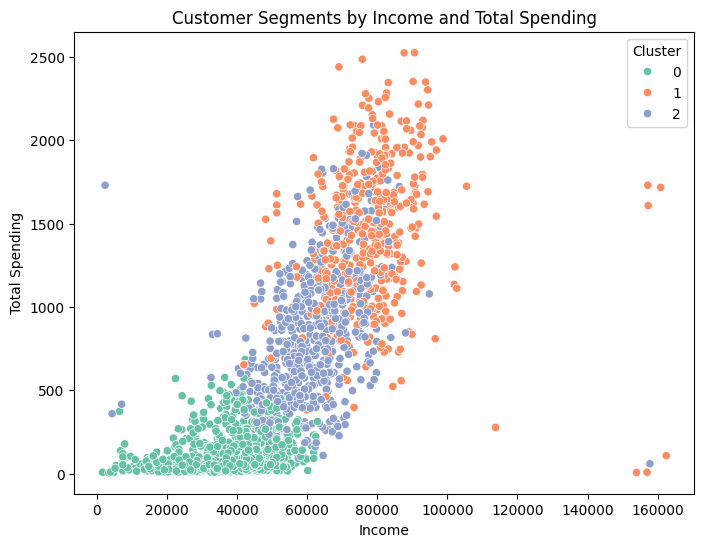

In [33]:
# Visualize customer segments by income and total spending

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=customer_clean,
    x="Income",
    y="Total_Spending",
    hue="Cluster",
    palette="Set2"
)

plt.title("Customer Segments by Income and Total Spending")
plt.xlabel("Income")
plt.ylabel("Total Spending")
plt.legend(title="Cluster")
plt.show()

In [54]:
# Add business labels to clusters

cluster_labels = {
    0: "Budget Browsers",
    1: "High-Value Loyalists",
    2: "Family-Oriented Regular Customers"
}

customer_clean["Segment_Label"] = customer_clean["Cluster"].map(cluster_labels)

display(customer_clean[["ID", "Cluster", "Segment_Label", "Income", "Total_Spending", "Total_Purchases"]].head())

,ID,Cluster,Segment_Label,Income,Total_Spending,Total_Purchases
0,5524,1,High-Value Loyalists,58138.0,1617,22
1,2174,0,Budget Browsers,46344.0,27,4
2,4141,1,High-Value Loyalists,71613.0,776,20
3,6182,0,Budget Browsers,26646.0,53,6
4,5324,2,Family-Oriented Regular Customers,58293.0,422,14


In [55]:
# Final segment summary for business interpretation

segment_summary = customer_clean.groupby("Segment_Label")[
    [
        "Income",
        "Age",
        "Total_Spending",
        "Total_Purchases",
        "Average_Order_Value",
        "Days_Since_Last_Purchase",
        "Campaign_Acceptance",
        "NumWebVisitsMonth"
    ]
].mean().round(2)

segment_summary["Customer_Count"] = customer_clean["Segment_Label"].value_counts()

display(segment_summary)

,Income,Age,Total_Spending,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Campaign_Acceptance,NumWebVisitsMonth,Customer_Count
Segment_Label,,,,,,,,,
Budget Browsers,34647.99,54.31,114.28,6.26,15.40,48.76,0.18,6.59,1087
Family-Oriented Regular Customers,61348.96,61.52,812.81,18.08,44.19,49.10,0.32,5.27,650
High-Value Loyalists,77408.54,57.44,1407.70,19.03,79.61,49.92,1.18,2.62,499


In [56]:
# Marketing strategy table for each customer segment

segment_strategy = pd.DataFrame({
    "Segment_Label": [
        "Budget Browsers",
        "High-Value Loyalists",
        "Family-Oriented Regular Customers"
    ],
    "Customer_Profile": [
        "Low income, low spending, high website visits, low purchase activity",
        "High income, high spending, frequent purchases, strong campaign response",
        "Medium-to-high income, regular purchases, mostly parents"
    ],
    "Marketing_Strategy": [
        "Use discounts, retargeting ads, simple offers, and conversion-focused campaigns",
        "Use loyalty programs, VIP offers, personalized recommendations, and retention campaigns",
        "Use family bundles, cross-selling, practical promotions, and personalized product suggestions"
    ]
})

display(segment_strategy)

,Segment_Label,Customer_Profile,Marketing_Strategy
0,Budget Browsers,"Low income, low spending, high website visits,...","Use discounts, retargeting ads, simple offers,..."
1,High-Value Loyalists,"High income, high spending, frequent purchases...","Use loyalty programs, VIP offers, personalized..."
2,Family-Oriented Regular Customers,"Medium-to-high income, regular purchases, most...","Use family bundles, cross-selling, practical p..."


### Customer Segmentation Interpretation

K-Means clustering divided customers into three meaningful marketing segments. The final model uses 3 clusters because the 4-cluster version created one extremely small segment with only one customer, which was not useful for business targeting.

The first segment is Budget Browsers. This is the largest group, with 1087 customers or 48.61% of the dataset. These customers have the lowest average income, about 34,647, and the lowest average spending, about 114. They also have the highest number of monthly website visits, around 6.59, but low purchase activity. This means they browse often but do not spend much. The best strategy for this group is to use discounts, simple offers, retargeting ads, and conversion-focused campaigns.

The second segment is High-Value Loyalists. This group includes 499 customers or 22.32% of the dataset. They have the highest average income, about 77,409, the highest average spending, about 1,408, and the highest average number of purchases, about 19. They also have the highest campaign acceptance score, around 1.18. This segment is the most valuable for the company. The best strategy is to use loyalty programs, premium offers, personalized recommendations, and VIP retention campaigns.

The third segment is Family-Oriented Regular Customers. This group includes 650 customers or 29.07% of the dataset. They have medium-to-high income, about 61,349, average spending of about 813, and high purchase activity, around 18 purchases. Most of them are parents, with Is_Parent close to 0.96. This means they are regular buyers with family-related needs. The best strategy is to offer family bundles, cross-selling, personalized product suggestions, and practical value-based promotions.

Overall, this segmentation helps the company understand who its customers are and move from general marketing to targeted strategies for each group.

## Task 4 — Predictive Customer Behavior Model

In this task, we build predictive models to forecast whether a customer is likely to respond to a marketing campaign. The target variable is Response, where 1 means that the customer responded to the latest campaign and 0 means that the customer did not respond.

Three models are compared: Logistic Regression, Random Forest Classifier, and XGBoost. Logistic Regression is used as a simple and interpretable baseline model. Random Forest is used because it can capture more complex relationships between customer variables. XGBoost is included as an advanced boosting model that often performs well in classification tasks.

The goal is not only to get high accuracy, but also to understand which model works better for identifying potential campaign responders. Since the target variable is imbalanced, the models are compared using accuracy, precision, recall, and F1 score.

The logistic regression model follows this formula:

P(Y = 1) = 1 / (1 + e^-(β₀ + β₁x₁ + β₂x₂ + ... + βₙxₙ))

In this project, Y = 1 means that the customer is predicted to respond to a marketing campaign.

In [45]:
# Prepare data for predictive modeling

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Try to import XGBoost
try:
    from xgboost import XGBClassifier
    xgboost_available = True
except:
    xgboost_available = False
    print("XGBoost is not available in this environment.")

# Create previous campaign acceptance without using the target variable Response
customer_clean["Previous_Campaign_Acceptance"] = (
    customer_clean["AcceptedCmp1"] +
    customer_clean["AcceptedCmp2"] +
    customer_clean["AcceptedCmp3"] +
    customer_clean["AcceptedCmp4"] +
    customer_clean["AcceptedCmp5"]
)

# Select features for prediction
prediction_features = [
    "Income",
    "Age",
    "Total_Spending",
    "Total_Purchases",
    "Average_Order_Value",
    "Days_Since_Last_Purchase",
    "Previous_Campaign_Acceptance",
    "NumWebVisitsMonth",
    "Is_Parent",
    "Family_Size",
    "Customer_Tenure_Days",
    "Education",
    "Marital_Status",
    "Segment_Label"
]

X = customer_clean[prediction_features]
y = customer_clean["Response"]

# Convert categorical variables into dummy variables
X = pd.get_dummies(X, drop_first=True)

print("Feature dataset shape:", X.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget distribution percentage:")
print((y.value_counts(normalize=True) * 100).round(2))

Feature dataset shape: (2236, 24)

Target distribution:
Response
0    1902
1     334
Name: count, dtype: int64

Target distribution percentage:
Response
0    85.06
1    14.94
Name: proportion, dtype: float64


In [46]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Standardize features for Logistic Regression
scaler_model = StandardScaler()

X_train_scaled = scaler_model.fit_transform(X_train)
X_test_scaled = scaler_model.transform(X_test)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (1788, 24)
Testing set shape: (448, 24)


In [47]:
# Build and compare Logistic Regression, Random Forest, and XGBoost

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42
    )
}

if xgboost_available:
    models["XGBoost"] = XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
        eval_metric="logloss"
    )

model_results = []

for model_name, model in models.items():

    # Logistic Regression uses scaled data
    if model_name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    model_results.append({
        "Model": model_name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1 Score": round(f1_score(y_test, y_pred), 4)
    })

model_comparison = pd.DataFrame(model_results)

display(model_comparison)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7902,0.3953,0.7612,0.5204
1,Random Forest,0.8862,0.8077,0.3134,0.4516
2,XGBoost,0.8862,0.7353,0.3731,0.4950


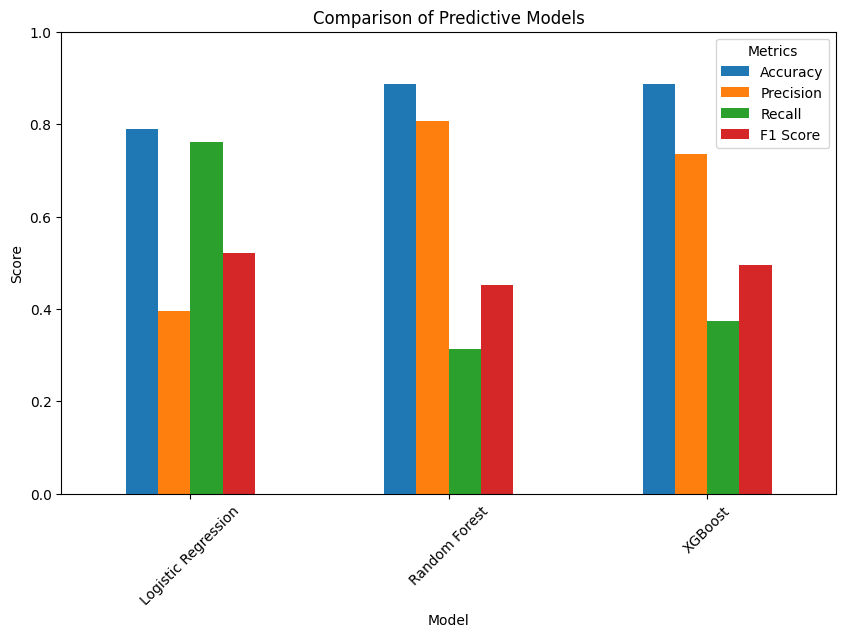

In [48]:
# Visualize model comparison

model_comparison.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparison of Predictive Models")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend(title="Metrics")
plt.show()

In [49]:
# Select the best model based on F1 Score

best_model_name = model_comparison.sort_values(
    by="F1 Score",
    ascending=False
).iloc[0]["Model"]

print("Best model based on F1 Score:", best_model_name)

Best model based on F1 Score: Logistic Regression


In [50]:
# Train the final model based on the best result

if best_model_name == "Logistic Regression":
    final_model = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    )
    final_model.fit(X_train_scaled, y_train)
    final_predictions = final_model.predict(X_test_scaled)

elif best_model_name == "Random Forest":
    final_model = RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42
    )
    final_model.fit(X_train, y_train)
    final_predictions = final_model.predict(X_test)

else:
    final_model = XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
        eval_metric="logloss"
    )
    final_model.fit(X_train, y_train)
    final_predictions = final_model.predict(X_test)

print("Final Model:", best_model_name)
print("Final Accuracy:", round(accuracy_score(y_test, final_predictions), 4))

Final Model: Logistic Regression
Final Accuracy: 0.7902


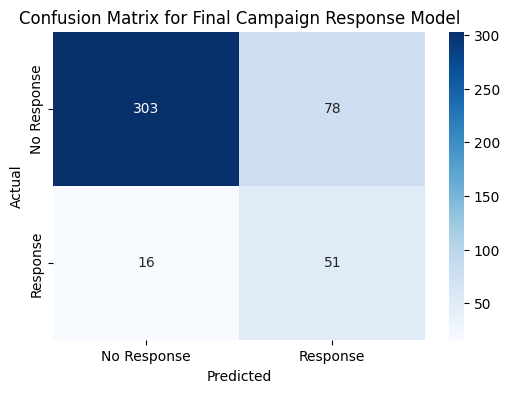

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.80      0.87       381
           1       0.40      0.76      0.52        67

    accuracy                           0.79       448
   macro avg       0.67      0.78      0.69       448
weighted avg       0.87      0.79      0.81       448



In [51]:
# Confusion matrix for the final model

cm = confusion_matrix(y_test, final_predictions)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Response", "Response"],
    yticklabels=["No Response", "Response"]
)

plt.title("Confusion Matrix for Final Campaign Response Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Classification Report:")
print(classification_report(y_test, final_predictions))

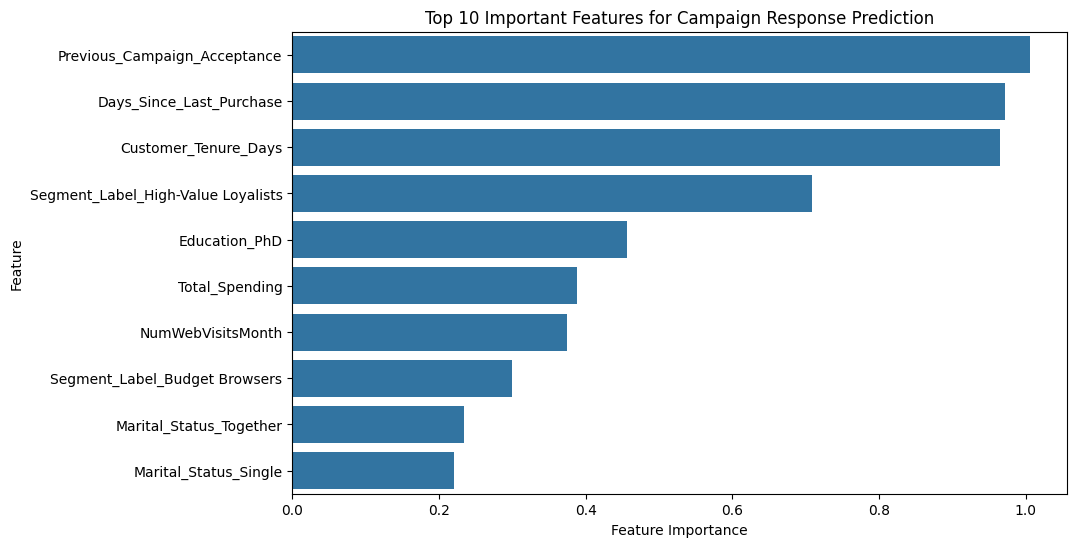

,Feature,Importance
6,Previous_Campaign_Acceptance,1.006002
5,Days_Since_Last_Purchase,0.971361
10,Customer_Tenure_Days,0.965419
23,Segment_Label_High-Value Loyalists,0.708696
14,Education_PhD,0.456366
2,Total_Spending,0.388903
7,NumWebVisitsMonth,0.374789
22,Segment_Label_Budget Browsers,0.299988
19,Marital_Status_Together,0.233987
18,Marital_Status_Single,0.221271


In [52]:
# Feature importance for the final model

if best_model_name == "Logistic Regression":
    feature_importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": abs(final_model.coef_[0])
    })
else:
    feature_importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": final_model.feature_importances_
    })

top_features = feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features for Campaign Response Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.show()

display(top_features)

In [57]:
# Add predicted campaign response probability to the customer dataset

if best_model_name == "Logistic Regression":
    X_all_scaled = scaler_model.transform(X)
    customer_clean["Predicted_Response"] = final_model.predict(X_all_scaled)
    customer_clean["Response_Probability"] = final_model.predict_proba(X_all_scaled)[:, 1]
else:
    customer_clean["Predicted_Response"] = final_model.predict(X)
    customer_clean["Response_Probability"] = final_model.predict_proba(X)[:, 1]

display(
    customer_clean[
        [
            "ID",
            "Segment_Label",
            "Response",
            "Predicted_Response",
            "Response_Probability",
            "Income",
            "Total_Spending",
            "Previous_Campaign_Acceptance"
        ]
    ].head()
)

,ID,Segment_Label,Response,Predicted_Response,Response_Probability,Income,Total_Spending,Previous_Campaign_Acceptance
0,5524,High-Value Loyalists,1,1,0.853441,58138.0,1617,0
1,2174,Budget Browsers,0,0,0.126456,46344.0,27,0
2,4141,High-Value Loyalists,0,0,0.290220,71613.0,776,0
3,6182,Budget Browsers,0,0,0.092176,26646.0,53,0
4,5324,Family-Oriented Regular Customers,0,0,0.012337,58293.0,422,0


### Predictive Model Interpretation

In this task, three predictive models were compared to forecast customer response to a marketing campaign: Logistic Regression, Random Forest Classifier, and XGBoost. The target variable was Response, where 1 means that the customer responded to the campaign and 0 means that the customer did not respond.

The dataset was imbalanced. Most customers did not respond to the campaign, while only a smaller share responded. Because of this, accuracy alone was not enough to choose the best model. Precision, recall, and F1 score were also used to evaluate model performance.

Random Forest and XGBoost achieved the highest accuracy, both with 0.8862. However, their recall scores were lower. Random Forest had recall of 0.3134, and XGBoost had recall of 0.3731. This means that these models were good at predicting non-responders, but they missed many actual responders.

Logistic Regression had lower accuracy, 0.7902, but it achieved the best recall of 0.7612 and the best F1 score of 0.5204. This means that Logistic Regression was better at identifying customers who are likely to respond to a campaign. For marketing, this is very important because the company wants to find potential responders and target them more effectively.

Therefore, Logistic Regression was selected as the final model based on F1 score. The confusion matrix shows that the model correctly predicted 303 non-responders and 51 responders. It missed only 16 actual responders, although it also produced 78 false positives. In a marketing context, this trade-off is acceptable because reaching some extra customers is usually less harmful than missing many potential responders.

The feature importance chart shows that Previous Campaign Acceptance was the strongest predictor of campaign response. This means that customers who accepted previous campaigns are more likely to respond again. Other important features included Days Since Last Purchase, Customer Tenure Days, High-Value Loyalist segment, PhD education, Total Spending, and Number of Web Visits per Month.

For the marketing team, this model can be used to prioritize customers with higher response probability. Instead of sending campaigns to all customers equally, the company can focus on customers who are more likely to respond. This can improve campaign efficiency, reduce wasted marketing budget, and support more personalized targeting.

### Model Comparison Summary

The model comparison shows that the best model depends on the business goal. Random Forest and XGBoost gave the highest accuracy, but Logistic Regression performed better for identifying actual campaign responders. Since the project goal is to support marketing targeting, F1 score and recall are more important than accuracy alone. For this reason, Logistic Regression was selected as the final predictive model.

## Task 5 — AI Recommendation and Personalization System

In this task, an AI recommendation system is created to support personalized marketing. The goal is to recommend product categories to each customer based on their own purchasing behavior and the behavior of similar customers.

The customer dataset does not contain separate product IDs or transaction-level product baskets. Therefore, the recommendation system works at the product category level. The available product categories are wines, fruits, meat products, fish products, sweet products, and gold products.

The system uses a similarity-based recommendation approach. First, it analyzes how much each customer spent in each product category. Then, it finds customers with similar purchase patterns using cosine similarity. Finally, it recommends categories where similar customers spend more than the selected customer. This logic helps identify cross-selling opportunities and supports personalized marketing campaigns.

In [58]:
# Prepare product category data for recommendation system

from sklearn.metrics.pairwise import cosine_similarity

# Product category columns from the customer dataset
product_category_columns = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

# Rename technical column names into business-friendly category names
category_names = {
    "MntWines": "Wines",
    "MntFruits": "Fruits",
    "MntMeatProducts": "Meat Products",
    "MntFishProducts": "Fish Products",
    "MntSweetProducts": "Sweet Products",
    "MntGoldProds": "Gold Products"
}

# Create customer-product category matrix
customer_product_matrix = customer_clean[product_category_columns].copy()

# Check the matrix
print("Customer-product matrix shape:", customer_product_matrix.shape)
display(customer_product_matrix.head())

Customer-product matrix shape: (2236, 6)


,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
0,635,88,546,172,88,88
1,11,1,6,2,1,6
2,426,49,127,111,21,42
3,11,4,20,10,3,5
4,173,43,118,46,27,15


In [59]:
# Standardize spending data before calculating similarity

recommendation_scaler = StandardScaler()
customer_product_scaled = recommendation_scaler.fit_transform(customer_product_matrix)

# Calculate customer similarity using cosine similarity
similarity_matrix = cosine_similarity(customer_product_scaled)

print("Similarity matrix shape:", similarity_matrix.shape)

Similarity matrix shape: (2236, 2236)


### Recommendation Logic

The recommendation system uses cosine similarity to compare customers. Cosine similarity helps measure how similar two customers are based on their spending patterns across product categories.

For each customer, the system finds similar customers and compares their average spending with the selected customer's current spending. If similar customers spend more in a certain category, that category becomes a recommendation opportunity.

In [60]:
# Function to display customer profile

def show_customer_profile(customer_id):
    """
    Display the selected customer's profile.
    """

    if customer_id not in customer_clean["ID"].values:
        return "Customer ID not found."

    profile = customer_clean[customer_clean["ID"] == customer_id][
        [
            "ID",
            "Segment_Label",
            "Income",
            "Age",
            "Total_Spending",
            "Total_Purchases",
            "Average_Order_Value",
            "Response_Probability"
        ]
    ]

    return profile

In [61]:
# Recommendation function based on similar customers

def recommend_product_categories(customer_id, top_n=3, similar_n=20):
    """
    Recommend product categories for a selected customer.

    customer_id: customer ID from the dataset
    top_n: number of recommended categories
    similar_n: number of similar customers used for recommendation
    """

    # Check if customer exists
    if customer_id not in customer_clean["ID"].values:
        return "Customer ID not found."

    # Find customer index in the original dataframe
    customer_index = customer_clean[customer_clean["ID"] == customer_id].index[0]

    # Convert dataframe index into matrix position
    matrix_index = customer_clean.index.get_loc(customer_index)

    # Get similarity scores for the selected customer
    similarity_scores = list(enumerate(similarity_matrix[matrix_index]))

    # Sort customers by similarity score and exclude the selected customer itself
    similar_customers = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )[1:similar_n + 1]

    # Get indexes of similar customers
    similar_indices = [customer[0] for customer in similar_customers]

    # Calculate average spending of similar customers
    similar_avg_spending = customer_product_matrix.iloc[similar_indices].mean()

    # Get current customer's spending
    current_customer_spending = customer_product_matrix.iloc[matrix_index]

    # Recommendation score shows where similar customers spend more
    recommendation_scores = similar_avg_spending - current_customer_spending

    # Create recommendation table
    recommendation_table = pd.DataFrame({
        "Product_Category": recommendation_scores.index.map(category_names),
        "Customer_Current_Spending": current_customer_spending.values,
        "Similar_Customers_Avg_Spending": similar_avg_spending.values,
        "Recommendation_Score": recommendation_scores.values
    })

    # Keep only categories where similar customers spend more
    recommendation_table = recommendation_table[
        recommendation_table["Recommendation_Score"] > 0
    ]

    # Rank recommendations
    recommendation_table = recommendation_table.sort_values(
        by="Recommendation_Score",
        ascending=False
    ).head(top_n)

    return recommendation_table

In [62]:
# Test recommendation system with one sample customer

sample_customer_id = customer_clean["ID"].iloc[0]

print("Sample Customer ID:", sample_customer_id)

display(show_customer_profile(sample_customer_id))

display(recommend_product_categories(sample_customer_id, top_n=3, similar_n=20))

Sample Customer ID: 5524


,ID,Segment_Label,Income,Age,Total_Spending,Total_Purchases,Average_Order_Value,Response_Probability
0,5524,High-Value Loyalists,58138.0,69,1617,22,73.5,0.853441


,Product_Category,Customer_Current_Spending,Similar_Customers_Avg_Spending,Recommendation_Score
0,Wines,635,650.1,15.1
4,Sweet Products,88,93.7,5.7
3,Fish Products,172,177.1,5.1


In [63]:
# Remove old recommendation columns if this cell is re-run
columns_to_remove = [
    "Top_Recommended_Category",
    "Recommendation_Score",
    "Personalized_AOV_Uplift_Proxy"
]

customer_clean = customer_clean.drop(
    columns=[col for col in columns_to_remove if col in customer_clean.columns],
    errors="ignore"
)

# Generate top recommendation for each customer
top_recommendations = []

for customer_id in customer_clean["ID"]:

    recommendations = recommend_product_categories(customer_id, top_n=1, similar_n=20)

    if isinstance(recommendations, pd.DataFrame) and len(recommendations) > 0:
        top_recommendations.append({
            "ID": customer_id,
            "Top_Recommended_Category": recommendations.iloc[0]["Product_Category"],
            "Recommendation_Score": recommendations.iloc[0]["Recommendation_Score"]
        })
    else:
        top_recommendations.append({
            "ID": customer_id,
            "Top_Recommended_Category": "No strong recommendation",
            "Recommendation_Score": 0
        })

recommendation_output = pd.DataFrame(top_recommendations)

# Merge recommendations back to customer dataset
customer_clean = customer_clean.merge(recommendation_output, on="ID", how="left")

display(
    customer_clean[
        [
            "ID",
            "Segment_Label",
            "Top_Recommended_Category",
            "Recommendation_Score",
            "Total_Spending",
            "Average_Order_Value"
        ]
    ].head()
)

,ID,Segment_Label,Top_Recommended_Category,Recommendation_Score,Total_Spending,Average_Order_Value
0,5524,High-Value Loyalists,Wines,15.10,1617,73.500000
1,2174,Budget Browsers,No strong recommendation,0.00,27,6.750000
2,4141,High-Value Loyalists,Meat Products,76.55,776,38.800000
3,6182,Budget Browsers,No strong recommendation,0.00,53,8.833333
4,5324,Family-Oriented Regular Customers,Fruits,1.35,422,30.142857


In [64]:
# Recommendation distribution by customer segment

recommendation_by_segment = pd.crosstab(
    customer_clean["Segment_Label"],
    customer_clean["Top_Recommended_Category"]
)

display(recommendation_by_segment)

Top_Recommended_Category,Fish Products,Fruits,Gold Products,Meat Products,No strong recommendation,Sweet Products,Wines
Segment_Label,,,,,,,
Budget Browsers,87,74,57,210,209,79,371
Family-Oriented Regular Customers,36,16,64,216,37,21,260
High-Value Loyalists,34,28,41,141,20,39,196


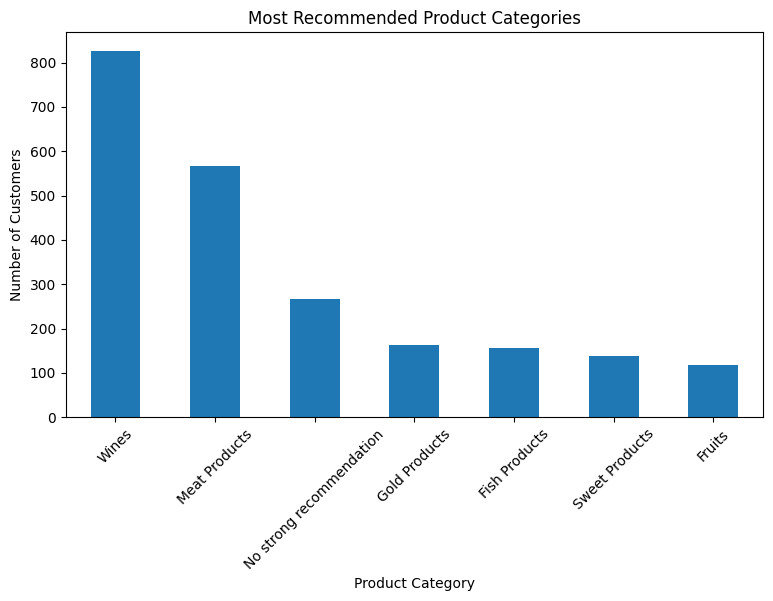

In [65]:
# Most recommended product categories overall

top_category_counts = customer_clean["Top_Recommended_Category"].value_counts()

plt.figure(figsize=(9, 5))
top_category_counts.plot(kind="bar")

plt.title("Most Recommended Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

,Recommendation_Score
Segment_Label,
High-Value Loyalists,86.74
Family-Oriented Regular Customers,80.92
Budget Browsers,7.77


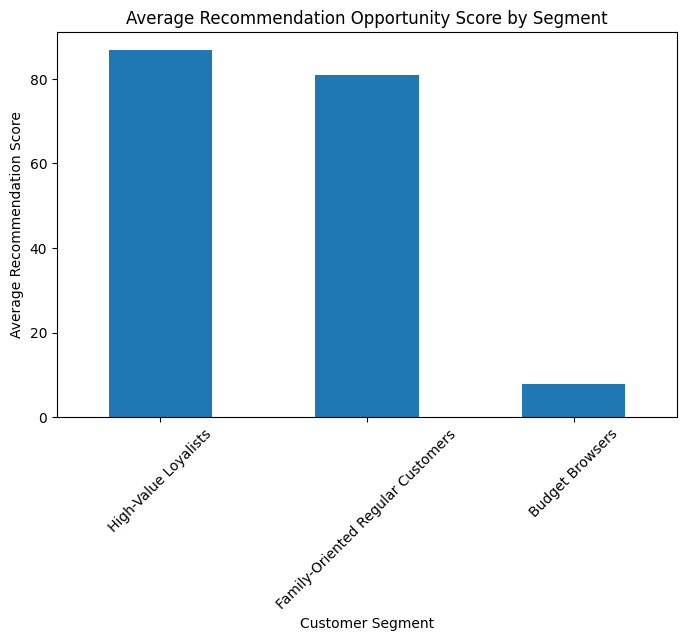

In [66]:
# Average recommendation score by segment

segment_recommendation_score = customer_clean.groupby("Segment_Label")[
    "Recommendation_Score"
].mean().round(2).sort_values(ascending=False)

display(segment_recommendation_score)

plt.figure(figsize=(8, 5))
segment_recommendation_score.plot(kind="bar")

plt.title("Average Recommendation Opportunity Score by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Recommendation Score")
plt.xticks(rotation=45)
plt.show()

In [67]:
# Business value proxy for personalization

# Generic recommendation means recommending the same most popular category to everyone
generic_category = customer_clean[product_category_columns].mean().idxmax()
generic_category_name = category_names[generic_category]

# Percentage of customers who receive a personalized recommendation different from generic recommendation
personalized_difference_rate = (
    customer_clean["Top_Recommended_Category"] != generic_category_name
).mean() * 100

# Average recommendation opportunity score
average_recommendation_score = customer_clean["Recommendation_Score"].mean()

# Conservative AOV uplift proxy:
# We assume only 5% of the recommendation opportunity converts into additional order value
customer_clean["Personalized_AOV_Uplift_Proxy"] = customer_clean["Recommendation_Score"] * 0.05

average_aov_uplift_proxy = customer_clean["Personalized_AOV_Uplift_Proxy"].mean()

print("Generic recommendation for all customers would be:", generic_category_name)
print("Customers receiving a personalized recommendation different from generic recommendation:",
      round(personalized_difference_rate, 2), "%")
print("Average recommendation opportunity score:", round(average_recommendation_score, 2))
print("Estimated average AOV uplift proxy:", round(average_aov_uplift_proxy, 2))

Generic recommendation for all customers would be: Wines
Customers receiving a personalized recommendation different from generic recommendation: 63.01 %
Average recommendation opportunity score: 46.66
Estimated average AOV uplift proxy: 2.33


In [68]:
# Create final recommendation table for Power BI

recommendation_powerbi = customer_clean[
    [
        "ID",
        "Segment_Label",
        "Income",
        "Age",
        "Total_Spending",
        "Total_Purchases",
        "Average_Order_Value",
        "Response_Probability",
        "Top_Recommended_Category",
        "Recommendation_Score",
        "Personalized_AOV_Uplift_Proxy"
    ]
].copy()

display(recommendation_powerbi.head())

# Save file for Power BI dashboard
recommendation_powerbi.to_csv("powerbi_recommendation_output.csv", index=False)

print("Recommendation output saved as powerbi_recommendation_output.csv")

,ID,Segment_Label,Income,Age,Total_Spending,Total_Purchases,Average_Order_Value,Response_Probability,Top_Recommended_Category,Recommendation_Score,Personalized_AOV_Uplift_Proxy
0,5524,High-Value Loyalists,58138.0,69,1617,22,73.500000,0.853441,Wines,15.10,0.7550
1,2174,Budget Browsers,46344.0,72,27,4,6.750000,0.126456,No strong recommendation,0.00,0.0000
2,4141,High-Value Loyalists,71613.0,61,776,20,38.800000,0.290220,Meat Products,76.55,3.8275
3,6182,Budget Browsers,26646.0,42,53,6,8.833333,0.092176,No strong recommendation,0.00,0.0000
4,5324,Family-Oriented Regular Customers,58293.0,45,422,14,30.142857,0.012337,Fruits,1.35,0.0675


Recommendation output saved as powerbi_recommendation_output.csv


### Recommendation System Interpretation

The recommendation system was created to personalize marketing offers at the product category level. Since the dataset does not include individual product IDs, the system recommends product categories: wines, fruits, meat products, fish products, sweet products, and gold products.

The system uses a similarity-based approach. It compares customers by their spending patterns across product categories using cosine similarity. For each customer, the model finds similar customers and checks which categories those similar customers spend more on. These gaps become recommendation opportunities.

For example, customer ID 5524 belongs to the High-Value Loyalists segment. This customer already has high total spending of 1617, 22 total purchases, and a high response probability of 0.853. The system recommended Wines, Sweet Products, and Fish Products. Wines had the highest recommendation score of 15.1, meaning that similar customers spend slightly more in this category than the selected customer.

The most recommended product category overall was Wines, followed by Meat Products. This shows that these two categories have the strongest cross-selling potential in the dataset. However, the system does not recommend the same category to everyone. Around 63.01% of customers received a personalized recommendation different from the generic recommendation. This proves that the system provides customer-level personalization instead of only promoting the most popular category.

The recommendation system also identified customers with no strong recommendation. This is useful because it prevents the company from forcing irrelevant offers when the customer's behavior does not show a clear cross-selling opportunity.

Overall, the recommendation engine helps the company move from general promotions to personalized marketing. It can support cross-selling, improve offer relevance, and help marketing teams choose which product category to promote to each customer segment.

### Business Value of Personalization

The business value of this recommendation system is connected to better targeting and stronger cross-selling. A generic campaign would recommend Wines to all customers because it is the most popular category overall. However, the personalized system gave 63.01% of customers a recommendation different from this generic option.

This means that most customers receive a more relevant offer based on their own behavior and the behavior of similar customers. The average recommendation opportunity score was 46.66, which shows that there is measurable potential to increase spending in recommended categories.

A conservative AOV uplift proxy was also calculated by assuming that only 5% of the recommendation opportunity converts into additional order value. Based on this assumption, the estimated average AOV uplift is 2.33 per customer. This is not a real financial result yet, but it gives the marketing team a simple way to estimate the possible value of personalization.

For High-Value Loyalists, recommendations can be used for premium cross-selling and loyalty campaigns. For Budget Browsers, they can support conversion through simple and relevant offers. For Family-Oriented Regular Customers, recommendations can support family bundles and practical product promotions.

In business terms, this system can help improve click-through rate, increase average order value, and reduce churn by keeping customers engaged with more relevant offers.

## Task 6 — Sentiment Analysis and Social Media Analytics

In this task, customer reviews are analyzed using Natural Language Processing. The goal is to understand the voice of the customer and classify review sentiment as positive, negative, or neutral.

The review dataset contains product names, prices, ratings, review text, summaries, and sentiment labels. A sentiment classification pipeline is built using TF-IDF text features and Logistic Regression. The model learns from review text and predicts whether the customer sentiment is positive, negative, or neutral.

The outputs include sentiment distribution, model evaluation, word clouds for positive and negative reviews, sentiment comparison across product categories, and marketing recommendations based on customer feedback.

In [69]:
# Prepare sentiment dataset for NLP analysis

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Copy cleaned sentiment dataset
sentiment_analysis = sentiment_clean.copy()

# Combine Review and Summary into one text column
sentiment_analysis["Text"] = (
    sentiment_analysis["Review"].astype(str) + " " +
    sentiment_analysis["Summary"].astype(str)
)

# Standardize sentiment labels
sentiment_analysis["Sentiment"] = sentiment_analysis["Sentiment"].str.lower().str.strip()

# Keep only valid sentiment classes
sentiment_analysis = sentiment_analysis[
    sentiment_analysis["Sentiment"].isin(["positive", "negative", "neutral"])
]

print("Sentiment analysis dataset shape:", sentiment_analysis.shape)

print("\nSentiment classes:")
print(sentiment_analysis["Sentiment"].value_counts())

display(sentiment_analysis[["ProductName", "Rate", "Text", "Sentiment"]].head())

Sentiment analysis dataset shape: (59941, 7)

Sentiment classes:
Sentiment
positive    44683
negative    11258
neutral      4000
Name: count, dtype: int64


,ProductName,Rate,Text,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,5.0,Super! great cooler excellent air flow and for...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,5.0,Awesome best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3.0,Fair the quality is good but the power of air ...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,1.0,Useless product very bad product its a only a fan,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3.0,Fair ok ok product,neutral


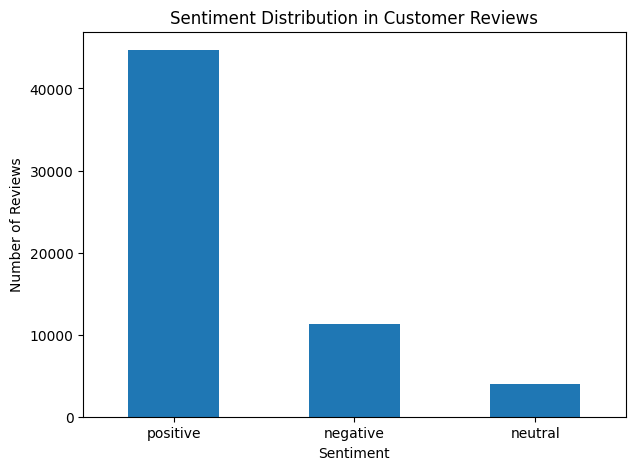

,count
Sentiment,
positive,44683
negative,11258
neutral,4000


In [70]:
# Sentiment distribution

sentiment_counts = sentiment_analysis["Sentiment"].value_counts()

plt.figure(figsize=(7, 5))
sentiment_counts.plot(kind="bar")

plt.title("Sentiment Distribution in Customer Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

display(sentiment_counts)

In [71]:
# Split data for sentiment classification

X_text = sentiment_analysis["Text"]
y_sentiment = sentiment_analysis["Sentiment"]

X_train_text, X_test_text, y_train_sentiment, y_test_sentiment = train_test_split(
    X_text,
    y_sentiment,
    test_size=0.2,
    random_state=42,
    stratify=y_sentiment
)

# Build NLP pipeline with TF-IDF and Logistic Regression
sentiment_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        max_features=5000,
        ngram_range=(1, 2)
    )),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

# Train model
sentiment_model.fit(X_train_text, y_train_sentiment)

# Predict sentiment
y_pred_sentiment = sentiment_model.predict(X_test_text)

# Accuracy
sentiment_accuracy = accuracy_score(y_test_sentiment, y_pred_sentiment)

print("Sentiment Classification Accuracy:", round(sentiment_accuracy, 4))

Sentiment Classification Accuracy: 0.879


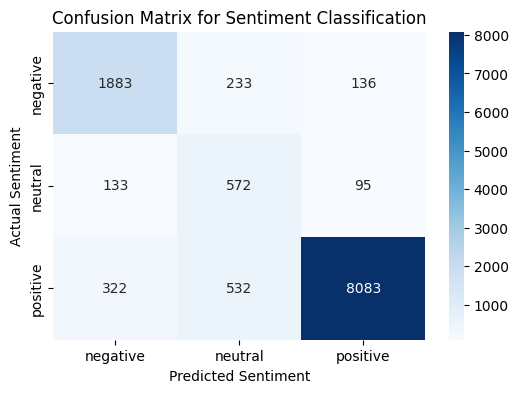

Classification Report:
              precision    recall  f1-score   support

    negative       0.81      0.84      0.82      2252
     neutral       0.43      0.71      0.54       800
    positive       0.97      0.90      0.94      8937

    accuracy                           0.88     11989
   macro avg       0.74      0.82      0.76     11989
weighted avg       0.90      0.88      0.89     11989



In [72]:
# Confusion matrix for sentiment classification

sentiment_labels = ["negative", "neutral", "positive"]

cm_sentiment = confusion_matrix(
    y_test_sentiment,
    y_pred_sentiment,
    labels=sentiment_labels
)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_sentiment,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sentiment_labels,
    yticklabels=sentiment_labels
)

plt.title("Confusion Matrix for Sentiment Classification")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.show()

print("Classification Report:")
print(classification_report(y_test_sentiment, y_pred_sentiment))

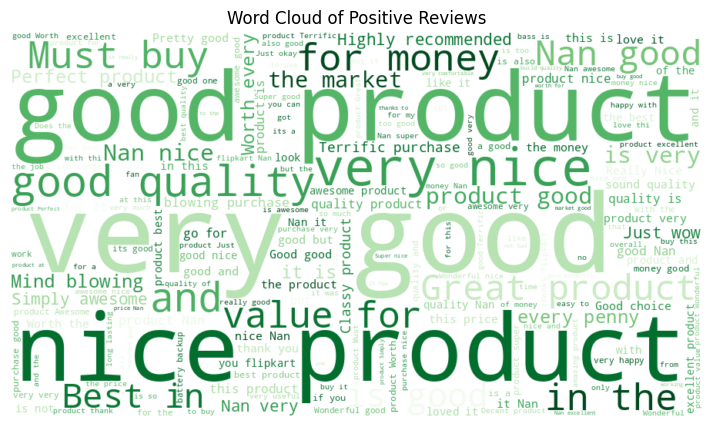

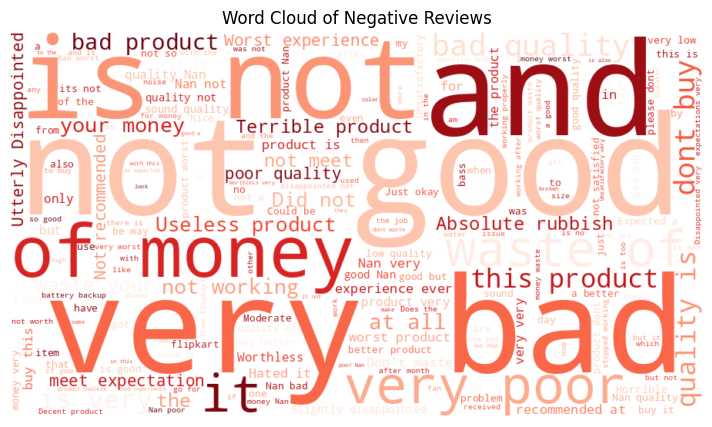

In [76]:
# Word clouds for positive and negative reviews

from wordcloud import WordCloud

positive_text = " ".join(
    sentiment_analysis[sentiment_analysis["Sentiment"] == "positive"]["Text"].astype(str)
)

negative_text = " ".join(
    sentiment_analysis[sentiment_analysis["Sentiment"] == "negative"]["Text"].astype(str)
)

# Positive word cloud
positive_wordcloud = WordCloud(
    width=900,
    height=500,
    background_color="white",
    stopwords="english",
    colormap="Greens"
).generate(positive_text)

plt.figure(figsize=(10, 5))
plt.imshow(positive_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Positive Reviews")
plt.show()

# Negative word cloud
negative_wordcloud = WordCloud(
    width=900,
    height=500,
    background_color="white",
    stopwords="english",
    colormap="Reds"
).generate(negative_text)

plt.figure(figsize=(10, 5))
plt.imshow(negative_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Negative Reviews")
plt.show()

In [77]:
# Create simple product category groups from product names

def assign_product_category(product_name):
    product_name = str(product_name).lower()

    if "cooler" in product_name or "fan" in product_name or "ac" in product_name:
        return "Cooling Products"
    elif "phone" in product_name or "mobile" in product_name:
        return "Mobile Products"
    elif "watch" in product_name:
        return "Watches"
    elif "shoe" in product_name or "sandal" in product_name:
        return "Footwear"
    elif "shirt" in product_name or "tshirt" in product_name or "t-shirt" in product_name:
        return "Clothing"
    elif "bag" in product_name:
        return "Bags"
    elif "laptop" in product_name or "computer" in product_name:
        return "Electronics"
    elif "beauty" in product_name or "cream" in product_name:
        return "Beauty Products"
    elif "kitchen" in product_name or "cook" in product_name:
        return "Kitchen Products"
    else:
        return "Other Products"

sentiment_analysis["Product_Category"] = sentiment_analysis["ProductName"].apply(assign_product_category)

print("Product category distribution:")
print(sentiment_analysis["Product_Category"].value_counts())

display(sentiment_analysis[["ProductName", "Product_Category", "Sentiment"]].head())

Product category distribution:
Product_Category
Cooling Products    33361
Other Products      20187
Kitchen Products     1854
Bags                 1379
Watches              1342
Clothing             1137
Footwear              491
Beauty Products       190
Name: count, dtype: int64


,ProductName,Product_Category,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,Cooling Products,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,Cooling Products,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,Cooling Products,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,Cooling Products,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,Cooling Products,neutral


In [78]:
# Sentiment distribution across product categories

category_sentiment = pd.crosstab(
    sentiment_analysis["Product_Category"],
    sentiment_analysis["Sentiment"],
    normalize="index"
) * 100

category_sentiment = category_sentiment.round(2)

display(category_sentiment)

Sentiment,negative,neutral,positive
Product_Category,,,
Bags,14.50,7.47,78.03
Beauty Products,17.89,8.95,73.16
Clothing,17.15,6.68,76.17
Cooling Products,19.80,6.55,73.65
Footwear,14.87,6.11,79.02
Kitchen Products,19.36,10.57,70.06
Other Products,18.45,6.72,74.83
Watches,5.07,2.61,92.32


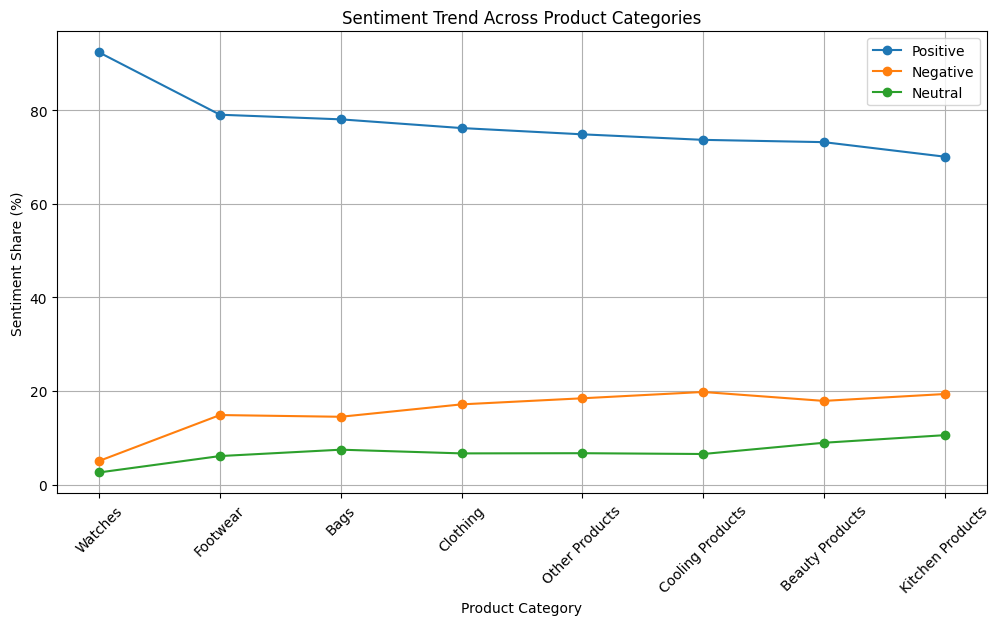

In [79]:
# Sentiment trend across product categories

category_sentiment_plot = category_sentiment.sort_values(
    by="positive",
    ascending=False
)

plt.figure(figsize=(12, 6))

plt.plot(
    category_sentiment_plot.index,
    category_sentiment_plot["positive"],
    marker="o",
    label="Positive"
)

plt.plot(
    category_sentiment_plot.index,
    category_sentiment_plot["negative"],
    marker="o",
    label="Negative"
)

plt.plot(
    category_sentiment_plot.index,
    category_sentiment_plot["neutral"],
    marker="o",
    label="Neutral"
)

plt.title("Sentiment Trend Across Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Sentiment Share (%)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

,Rate
Sentiment,
negative,1.52
neutral,2.92
positive,4.57


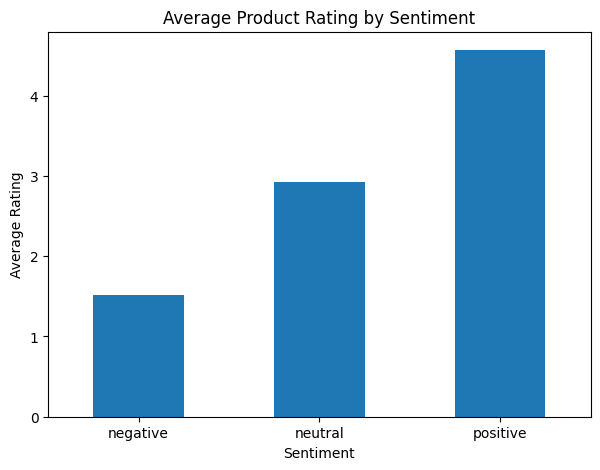

In [80]:
# Average rating by sentiment

rating_by_sentiment = sentiment_analysis.groupby("Sentiment")["Rate"].mean().round(2)

display(rating_by_sentiment)

plt.figure(figsize=(7, 5))
rating_by_sentiment.plot(kind="bar")

plt.title("Average Product Rating by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Rating")
plt.xticks(rotation=0)
plt.show()

In [81]:
# Top categories by positive and negative sentiment

category_sentiment_counts = pd.crosstab(
    sentiment_analysis["Product_Category"],
    sentiment_analysis["Sentiment"]
)

category_sentiment_counts["Total_Reviews"] = category_sentiment_counts.sum(axis=1)
category_sentiment_counts["Positive_Rate"] = (
    category_sentiment_counts["positive"] / category_sentiment_counts["Total_Reviews"] * 100
).round(2)
category_sentiment_counts["Negative_Rate"] = (
    category_sentiment_counts["negative"] / category_sentiment_counts["Total_Reviews"] * 100
).round(2)

display(
    category_sentiment_counts.sort_values(
        by="Negative_Rate",
        ascending=False
    )
)

Sentiment,negative,neutral,positive,Total_Reviews,Positive_Rate,Negative_Rate
Product_Category,,,,,,
Cooling Products,6605,2186,24570,33361,73.65,19.80
Kitchen Products,359,196,1299,1854,70.06,19.36
Other Products,3724,1357,15106,20187,74.83,18.45
Beauty Products,34,17,139,190,73.16,17.89
Clothing,195,76,866,1137,76.17,17.15
Footwear,73,30,388,491,79.02,14.87
Bags,200,103,1076,1379,78.03,14.50
Watches,68,35,1239,1342,92.32,5.07


In [82]:
# Create sentiment output for Power BI

sentiment_powerbi = sentiment_analysis[
    [
        "ProductName",
        "Product_Category",
        "ProductPrice",
        "Rate",
        "Review",
        "Summary",
        "Sentiment"
    ]
].copy()

sentiment_powerbi.to_csv("powerbi_sentiment_output.csv", index=False)

print("Sentiment output saved as powerbi_sentiment_output.csv")
display(sentiment_powerbi.head())

Sentiment output saved as powerbi_sentiment_output.csv


,ProductName,Product_Category,ProductPrice,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,Cooling Products,3999.0,5.0,Super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,Cooling Products,3999.0,5.0,Awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,Cooling Products,3999.0,3.0,Fair,the quality is good but the power of air is de...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,Cooling Products,3999.0,1.0,Useless product,very bad product its a only a fan,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,Cooling Products,3999.0,3.0,Fair,ok ok product,neutral


### Sentiment Analysis Interpretation

The sentiment analysis was conducted using the cleaned review dataset with 59,941 reviews. The dataset contains three sentiment classes: positive, negative, and neutral. Most reviews are positive: 44,683 reviews are positive, 11,258 are negative, and 4,000 are neutral. This means that the general customer mood is mostly favorable, but there is still a noticeable group of dissatisfied customers that the marketing team should not ignore.

A Natural Language Processing pipeline was built using TF-IDF and Logistic Regression. TF-IDF transformed review text into numerical features, while Logistic Regression classified the reviews into positive, negative, and neutral sentiment. The model achieved an accuracy of 0.879, which means it correctly classified about 88% of reviews.

The classification report shows that the model performs best on positive reviews, with precision of 0.97 and recall of 0.90. It also performs well on negative reviews, with precision of 0.81 and recall of 0.84. Neutral sentiment is harder to classify, with precision of 0.43 and F1-score of 0.54. This is expected because neutral reviews often contain mixed or unclear language.

The word clouds show clear differences between positive and negative customer language. Positive reviews often include words such as “good product,” “nice product,” “very good,” “good quality,” and “value for money.” This means customers mostly praise product quality, usefulness, and price-value balance. Negative reviews often include words such as “not good,” “very bad,” “money waste,” “bad quality,” and “poor.” These words show that dissatisfied customers mainly complain about product quality and unmet expectations.

Since the dataset does not include review dates, sentiment trend was analyzed across product categories. Watches have the strongest positive sentiment, with 92.32% positive reviews and only 5.07% negative reviews. Footwear, Bags, and Clothing also show relatively strong positive sentiment, with positive rates around 76–79%. The weakest categories are Kitchen Products and Cooling Products. Kitchen Products have only 70.06% positive reviews and 19.36% negative reviews, while Cooling Products have 73.65% positive reviews and the highest negative review count because this category has the largest number of reviews.

Average rating also supports the sentiment results. Positive reviews have an average rating of 4.57, neutral reviews have 2.92, and negative reviews have 1.52. This confirms that the sentiment labels are consistent with customer ratings.

Overall, sentiment analysis shows that the brand has a generally positive customer perception, but some categories require attention. The marketing team should actively promote categories with strong positive sentiment, especially Watches, Footwear, Bags, and Clothing. At the same time, Kitchen Products and Cooling Products should be reviewed for product quality, expectation mismatch, and customer complaints before increasing advertising budget.

### Marketing Recommendation Based on Sentiment

The marketing team should use positive customer language in campaigns. Phrases connected with “good quality,” “nice product,” and “value for money” can be used in ad messages, product pages, and social media content because they reflect what satisfied customers already appreciate.

For high-performing categories such as Watches, Footwear, Bags, and Clothing, the company can increase promotion because these categories have strong positive sentiment. These products can be used in trust-building campaigns, customer testimonials, and recommendation blocks.

For Cooling Products and Kitchen Products, the company should first investigate negative reviews before scaling promotion. The main negative signals are connected with poor quality, bad experience, and money waste. Marketing should work with product and customer support teams to improve product descriptions, manage expectations, and fix repeated complaints.

Neutral reviews should also be monitored because they may represent customers who are not fully satisfied. These customers can be targeted with better product education, clearer descriptions, and follow-up offers.

In general, sentiment analysis should be used as a feedback loop for marketing decisions. Positive sentiment can guide promotion, while negative sentiment should guide product improvement and customer service priorities.

In [83]:
customer_clean.to_csv("powerbi_customer_final.csv", index=False)

In [84]:
segment_summary.to_csv("powerbi_segment_summary.csv")
model_comparison.to_csv("powerbi_model_comparison.csv", index=False)
category_sentiment.to_csv("powerbi_category_sentiment.csv")
recommendation_by_segment.to_csv("powerbi_recommendation_by_segment.csv")